<a href="https://colab.research.google.com/github/vchauhan23/ML-Assessment/blob/main/Case_Study_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [3]:
# Load the CSV file
df = pd.read_csv("diabetic_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display number of rows and columns
print("Shape of dataset:", df.shape)

# Display first 5 rows
print("\nFirst 5 rows:")
print(df.head())

Shape of dataset: (16686, 50)

First 5 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                6.0                      25.0                  1.0   
1                1.0                       1.0                  7.0   
2                1.0                       1.0                  7.0   
3                1.0                       1.0                  7.0   
4                1.0                       1.0                  7.0   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0               1.0 

In [5]:
#Data Pre-processing
print("\nColumn names:")
print(df.columns)


Column names:
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [6]:
#check missing value
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
encounter_id                    0
patient_nbr                     0
race                            1
gender                          1
age                             1
weight                          1
admission_type_id               1
discharge_disposition_id        1
admission_source_id             1
time_in_hospital                1
payer_code                      1
medical_specialty               1
num_lab_procedures              1
num_procedures                  1
num_medications                 1
number_outpatient               1
number_emergency                1
number_inpatient                1
diag_1                          1
diag_2                          1
diag_3                          1
number_diagnoses                1
max_glu_serum               15085
A1Cresult                   13560
metformin                       1
repaglinide                     1
nateglinide                     1
chlorpropamide                  1
glimepiride                    

In [7]:
#  Replace '?' with NaN
df = df.replace("?", np.nan)

print("\nMissing values after replacing '?':")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Missing values after replacing '?':
payer_code           16686
weight               16165
max_glu_serum        15085
A1Cresult            13560
medical_specialty     6574
diag_3                 476
race                   284
diag_2                 101
diag_1                   8
time_in_hospital         1
dtype: int64


/tmp/ipykernel_701/2473826917.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("?", np.nan)


In [8]:
# Remove columns with too many missing values

columns_to_remove = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df = df.drop(columns=columns_to_remove)

In [9]:
# Remove unncessary column

columns_to_remove = [
    "encounter_id",
    "patient_nbr"
]

df = df.drop(columns=columns_to_remove)

In [10]:
#  CREATE TARGET VARIABLE

df["readmitted"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

print("\nTarget distribution:")
print(df["readmitted"].value_counts())


Target distribution:
readmitted
0    14829
1     1857
Name: count, dtype: int64


In [11]:
#  HANDLE MISSING VALUES

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    df[column] = df[column].fillna("Unknown")


# Fill missing numerical values with median

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:

    if column != "readmitted":
        df[column] = df[column].fillna(df[column].median())

In [12]:
# CONVERT CATEGORICAL DATA INTO NUMBERS

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("\nShape after preprocessing:", df.shape)


Shape after preprocessing: (16686, 1636)


In [13]:
# SEPARATE FEATURES AND TARGET

X = df.drop("readmitted", axis=1)

y = df["readmitted"]


print("\nNumber of features:", X.shape[1])
print("Number of records:", X.shape[0])


Number of features: 1635
Number of records: 16686


In [14]:
#Train test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (13348, 1635)
Testing data: (3338, 1635)


In [15]:
# FEATURE SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
# logistic regression without l2

model_without_l2 = LogisticRegression(
    penalty=None,
    max_iter=1000
)

In [17]:
#train model without l2
model_without_l2.fit(X_train, y_train)

print("\nModel without L2 trained successfully!")


Model without L2 trained successfully!


In [18]:
#  PREDICTION WITHOUT L2

y_probability_without_l2 = model_without_l2.predict_proba(
    X_test
)[:, 1]
y_prediction_without_l2 = (
    y_probability_without_l2 >= 0.5
).astype(int)

In [19]:
#  ROC-AUC WITHOUT L2
auc_without_l2 = roc_auc_score(
    y_test,
    y_probability_without_l2
)

print("\nROC-AUC without L2:", auc_without_l2)


ROC-AUC without L2: 0.5717065619387385


In [20]:
#CONFUSION MATRIX WITHOUT L2
cm_without_l2 = confusion_matrix(
    y_test,
    y_prediction_without_l2
)

print("\nConfusion Matrix - Without L2:")
print(cm_without_l2)


Confusion Matrix - Without L2:
[[2906   61]
 [ 357   14]]


In [21]:
# FALSE NEGATIVES WITHOUT L2
tn, fp, fn, tp = cm_without_l2.ravel()

print("\nWithout L2:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


Without L2:
True Negatives : 2906
False Positives: 61
False Negatives: 357
True Positives : 14


In [22]:
# LOGISTIC REGRESSION WITH L2
model_with_l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000
)


In [23]:
# TRAIN MODEL WITH L2
model_with_l2.fit(X_train, y_train)

print("\nModel with L2 trained successfully!")


Model with L2 trained successfully!


In [24]:
#  PREDICTION WITH L2
y_probability_with_l2 = model_with_l2.predict_proba(
    X_test
)[:, 1]

y_prediction_with_l2 = (
    y_probability_with_l2 >= 0.5
).astype(int)

In [25]:
#  ROC-AUC WITH L2
auc_with_l2 = roc_auc_score(
    y_test,
    y_probability_with_l2
)

print("\nROC-AUC with L2:", auc_with_l2)


ROC-AUC with L2: 0.5715357703834725


In [26]:
# CONFUSION MATRIX WITH L2
cm_with_l2 = confusion_matrix(
    y_test,
    y_prediction_with_l2
)

print("\nConfusion Matrix - With L2:")
print(cm_with_l2)


Confusion Matrix - With L2:
[[2906   61]
 [ 357   14]]


In [27]:
# FALSE NEGATIVES WITH L2
tn, fp, fn, tp = cm_with_l2.ravel()

print("\nWith L2:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


With L2:
True Negatives : 2906
False Positives: 61
False Negatives: 357
True Positives : 14


In [28]:
# CLASSIFICATION REPORT
print("\nClassification Report - Without L2:")
print(
    classification_report(
        y_test,
        y_prediction_without_l2
    )
)


print("\nClassification Report - With L2:")
print(
    classification_report(
        y_test,
        y_prediction_with_l2
    )
)


Classification Report - Without L2:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2967
           1       0.19      0.04      0.06       371

    accuracy                           0.87      3338
   macro avg       0.54      0.51      0.50      3338
weighted avg       0.81      0.87      0.84      3338


Classification Report - With L2:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2967
           1       0.19      0.04      0.06       371

    accuracy                           0.87      3338
   macro avg       0.54      0.51      0.50      3338
weighted avg       0.81      0.87      0.84      3338



In [29]:

#  COMPARE ROC-AUC

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print("ROC-AUC without L2:", auc_without_l2)
print("ROC-AUC with L2   :", auc_with_l2)


MODEL COMPARISON
ROC-AUC without L2: 0.5717065619387385
ROC-AUC with L2   : 0.5715357703834725


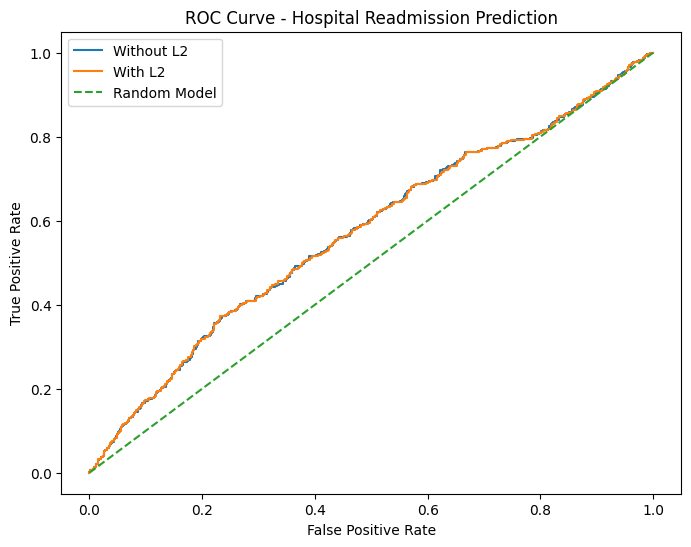

In [30]:

#  ROC CURVE

fpr_without_l2, tpr_without_l2, thresholds = roc_curve(
    y_test,
    y_probability_without_l2
)

fpr_with_l2, tpr_with_l2, thresholds = roc_curve(
    y_test,
    y_probability_with_l2
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr_without_l2,
    tpr_without_l2,
    label="Without L2"
)

plt.plot(
    fpr_with_l2,
    tpr_with_l2,
    label="With L2"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Hospital Readmission Prediction")

plt.legend()

plt.show()

In [31]:
#  FINAL FALSE NEGATIVE COMPARISON

tn1, fp1, fn1, tp1 = cm_without_l2.ravel()

tn2, fp2, fn2, tp2 = cm_with_l2.ravel()

print("\n==============================")
print("FALSE NEGATIVE COMPARISON")
print("==============================")

print("False Negatives without L2:", fn1)
print("False Negatives with L2   :", fn2)

print("\nFalse Positives without L2:", fp1)
print("False Positives with L2   :", fp2)


FALSE NEGATIVE COMPARISON
False Negatives without L2: 357
False Negatives with L2   : 357

False Positives without L2: 61
False Positives with L2   : 61
